## Imports

In [8]:
from environment import Environment
from agent import Agent

In [2]:
from tensorflow.keras.models import load_model

## Loading Trained Model

In [3]:
model_path=r"/home/spiralmonster/Projects/ReinforcementLearningForFinance/DynamicHedging/Models/model_version_1_o.keras"

In [4]:
model=load_model(model_path)

2025-06-22 18:41:47.598172: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 6, 2)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 6, 2)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 6, 2)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 6, 8)      │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 6, 4)      │        112 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 6, 4)      │        112 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 6, 4)      │        112 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 6, 16)     │      1,600 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 6, 8)      │        416 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 6, 8)      │        416 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ (None, 6, 8)      │        416 │ lstm_9[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        144 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │      6,272 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 16)        │      1,600 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 16)        │      1,600 │ lstm_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 16)        │      1,600 │ lstm_10[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        544 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112)       │          0 │ lstm_2[0][0],     │
│ (Concatenate)       │                   │            │ lstm_5[0][0],     │
│                     │                   │            │ lstm_8[0][0],     │
│                     │                   │            │ lstm_11[0][0],    │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 241,349 (942.77 KB)

 Trainable params: 80,449 (314.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 160,900 (628.52 KB)

## Environment

In [6]:
env=Environment(
    symbol="AAPL",
    short_rate=0.05,
    maturity=4.0,
    steps=1000,
    number_lags=5,
    window=10
)

## Agent

In [7]:
agent=Agent(
    env=env,
    model_config=None,
    optimizer_config=None,
    batch_size=128,
    buffer_size=2000,
    gamma=0.7,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.9975,
    model_trained=True
)

## Assigning Trained Model to Agent

In [9]:
agent.model=model

## Testing Agent

Testing| Total Reward: -5086.383750651981| Average Reward: -6.163841371220285| Average Profit-Loss: -1.909419396670435| Average Profit-Loss%: -1.9981576121053164| MAE between Option Value and Replication Portfolio: 1.3195941377308396| MSE between theoretical and predicted delta: 0.4702175346619416| MSE between real and predicted Qvalue: 412.6373720330723| 


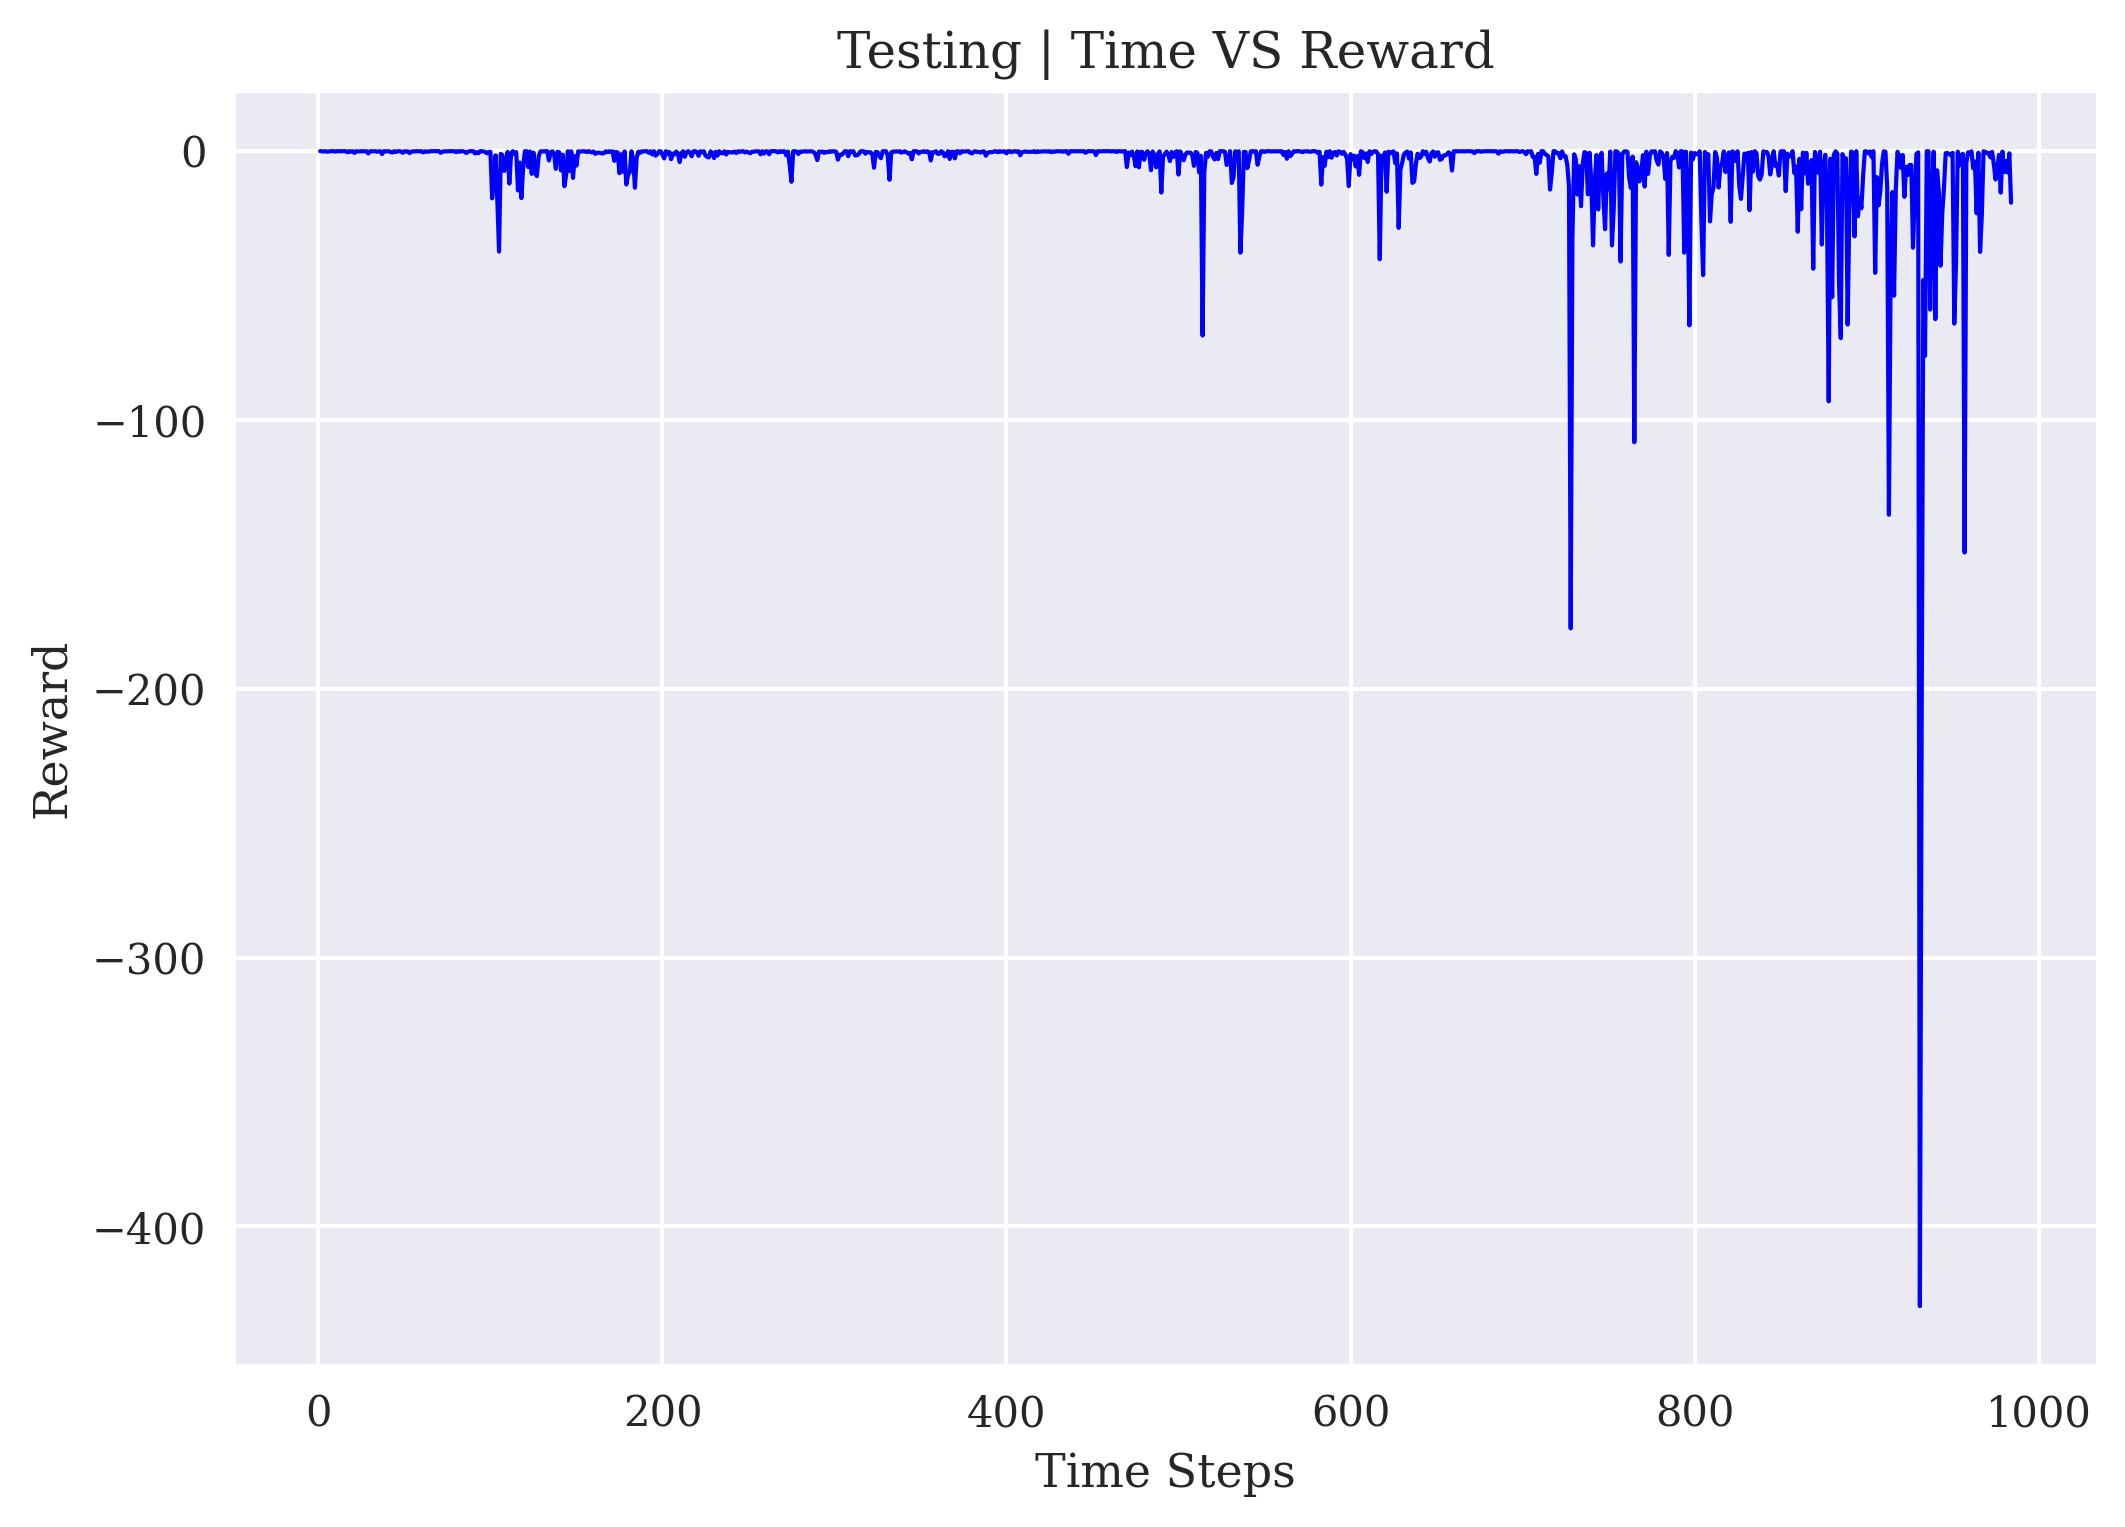

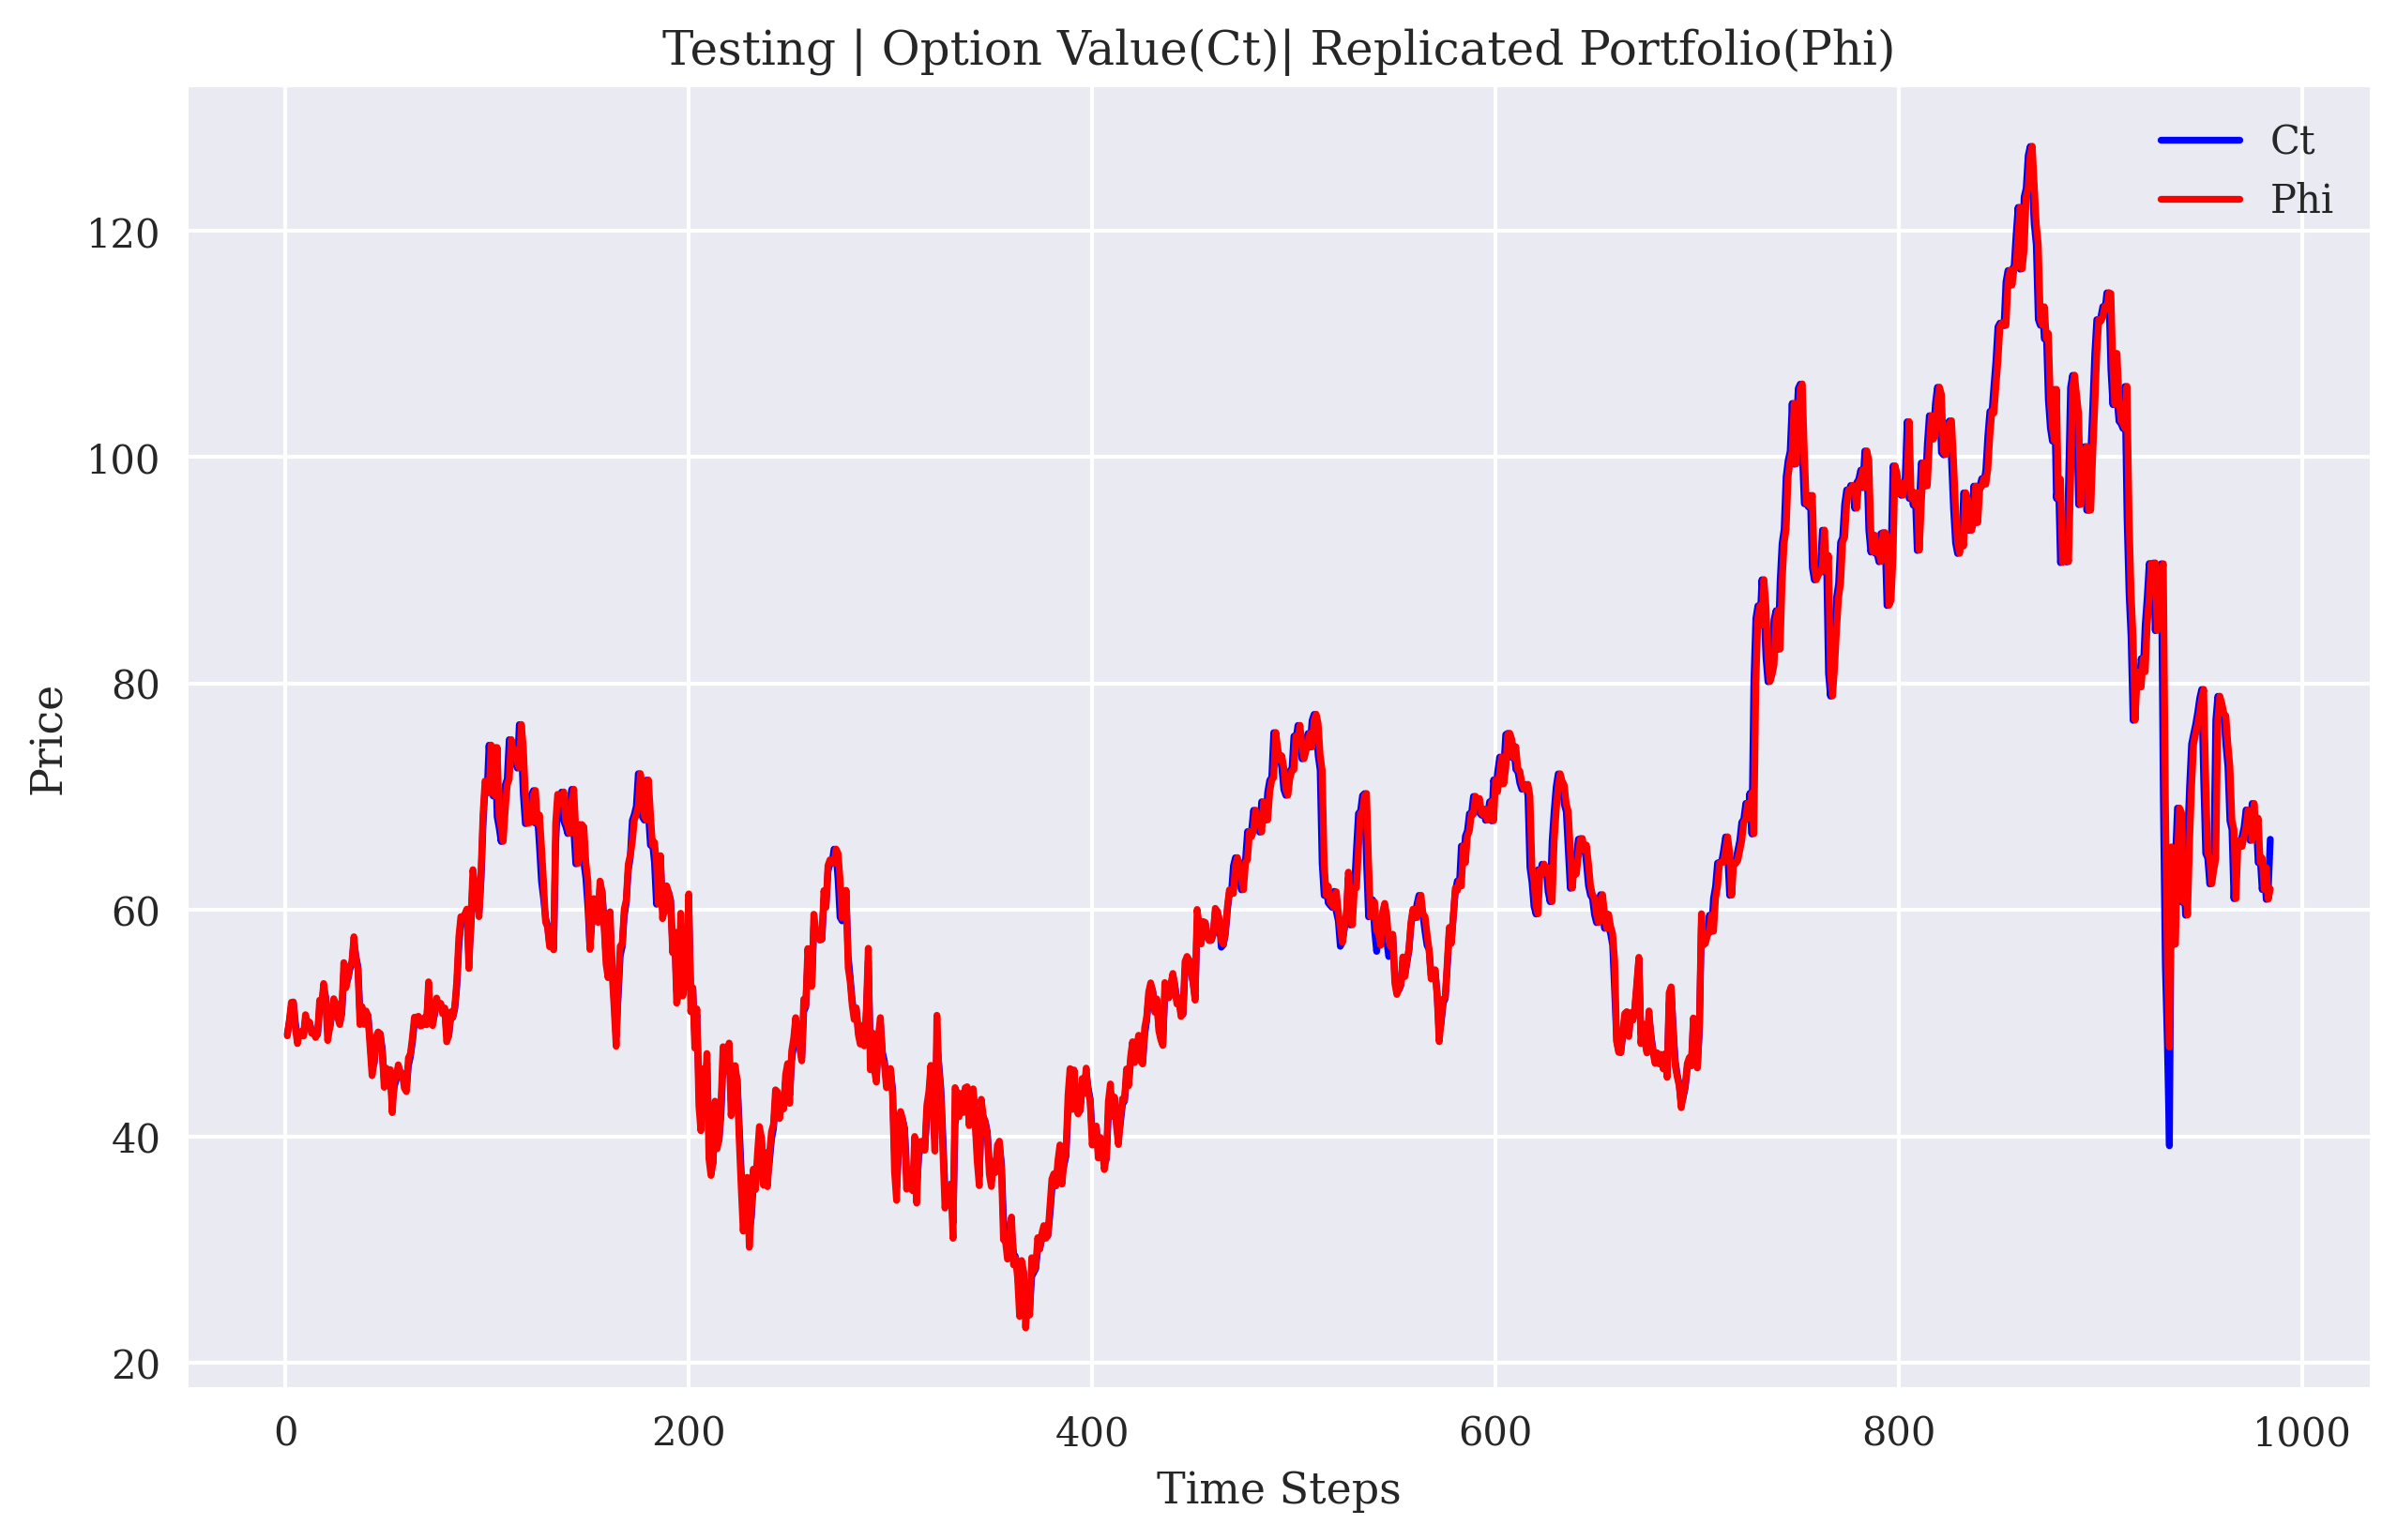

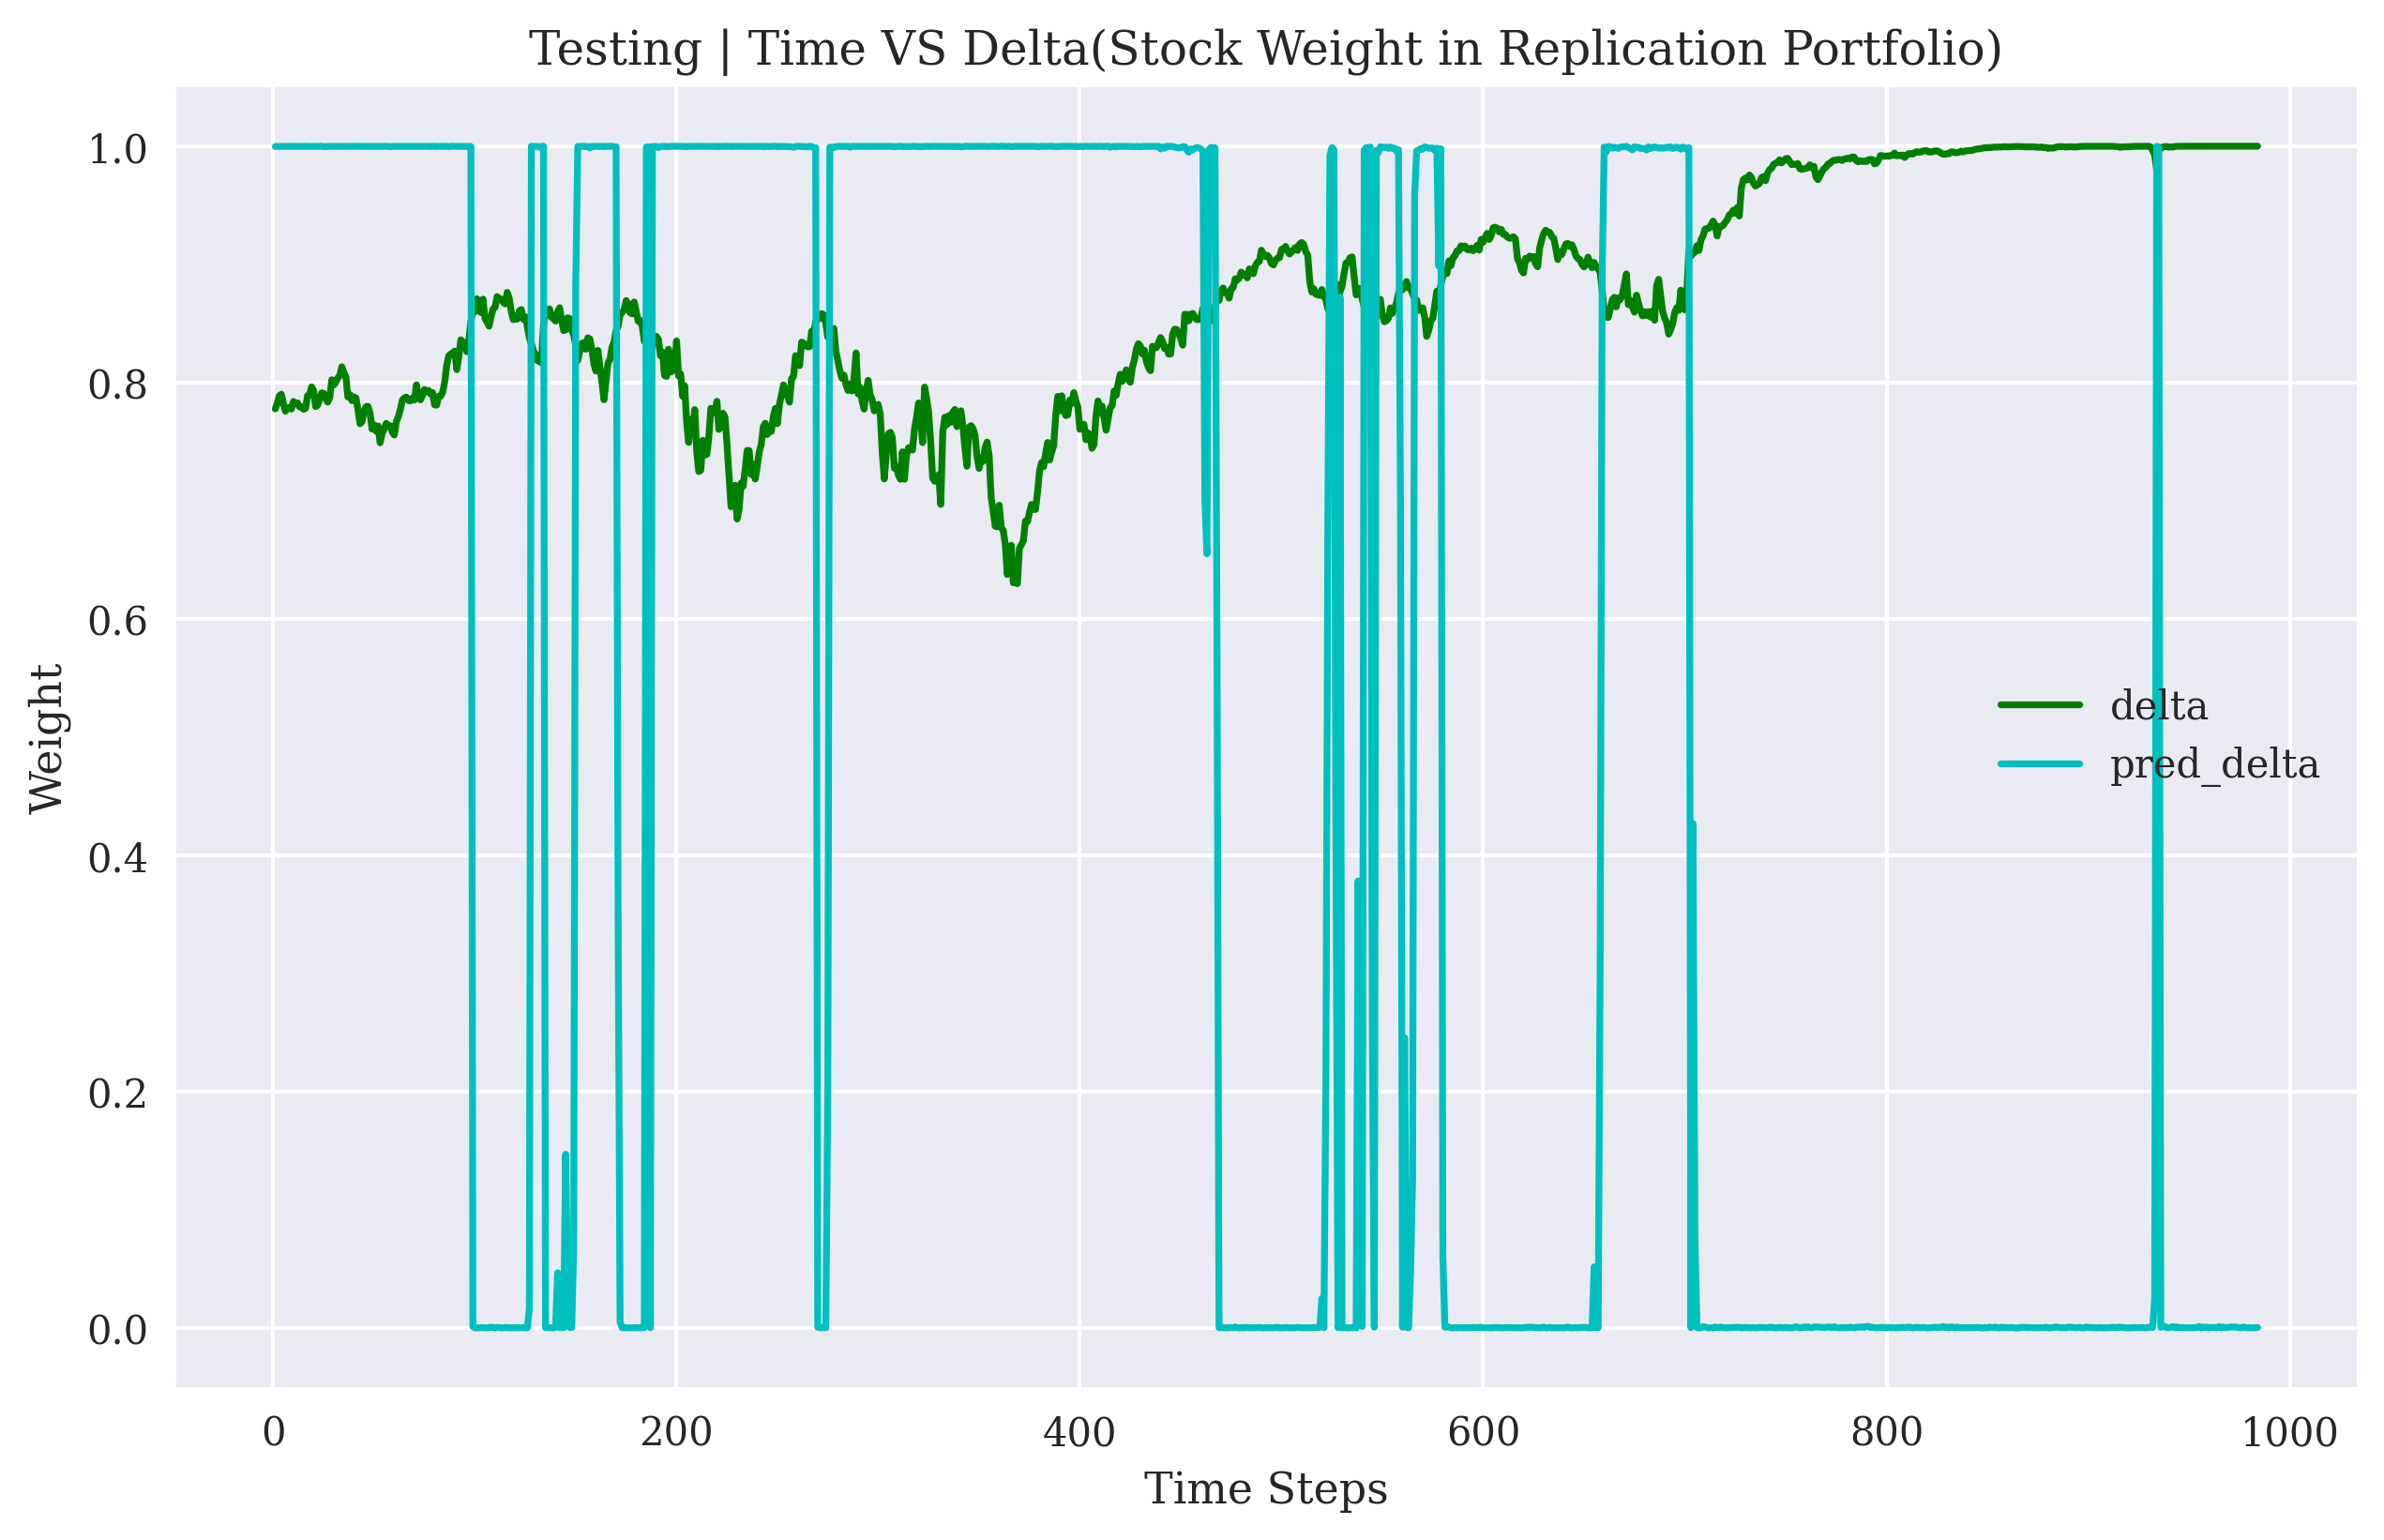

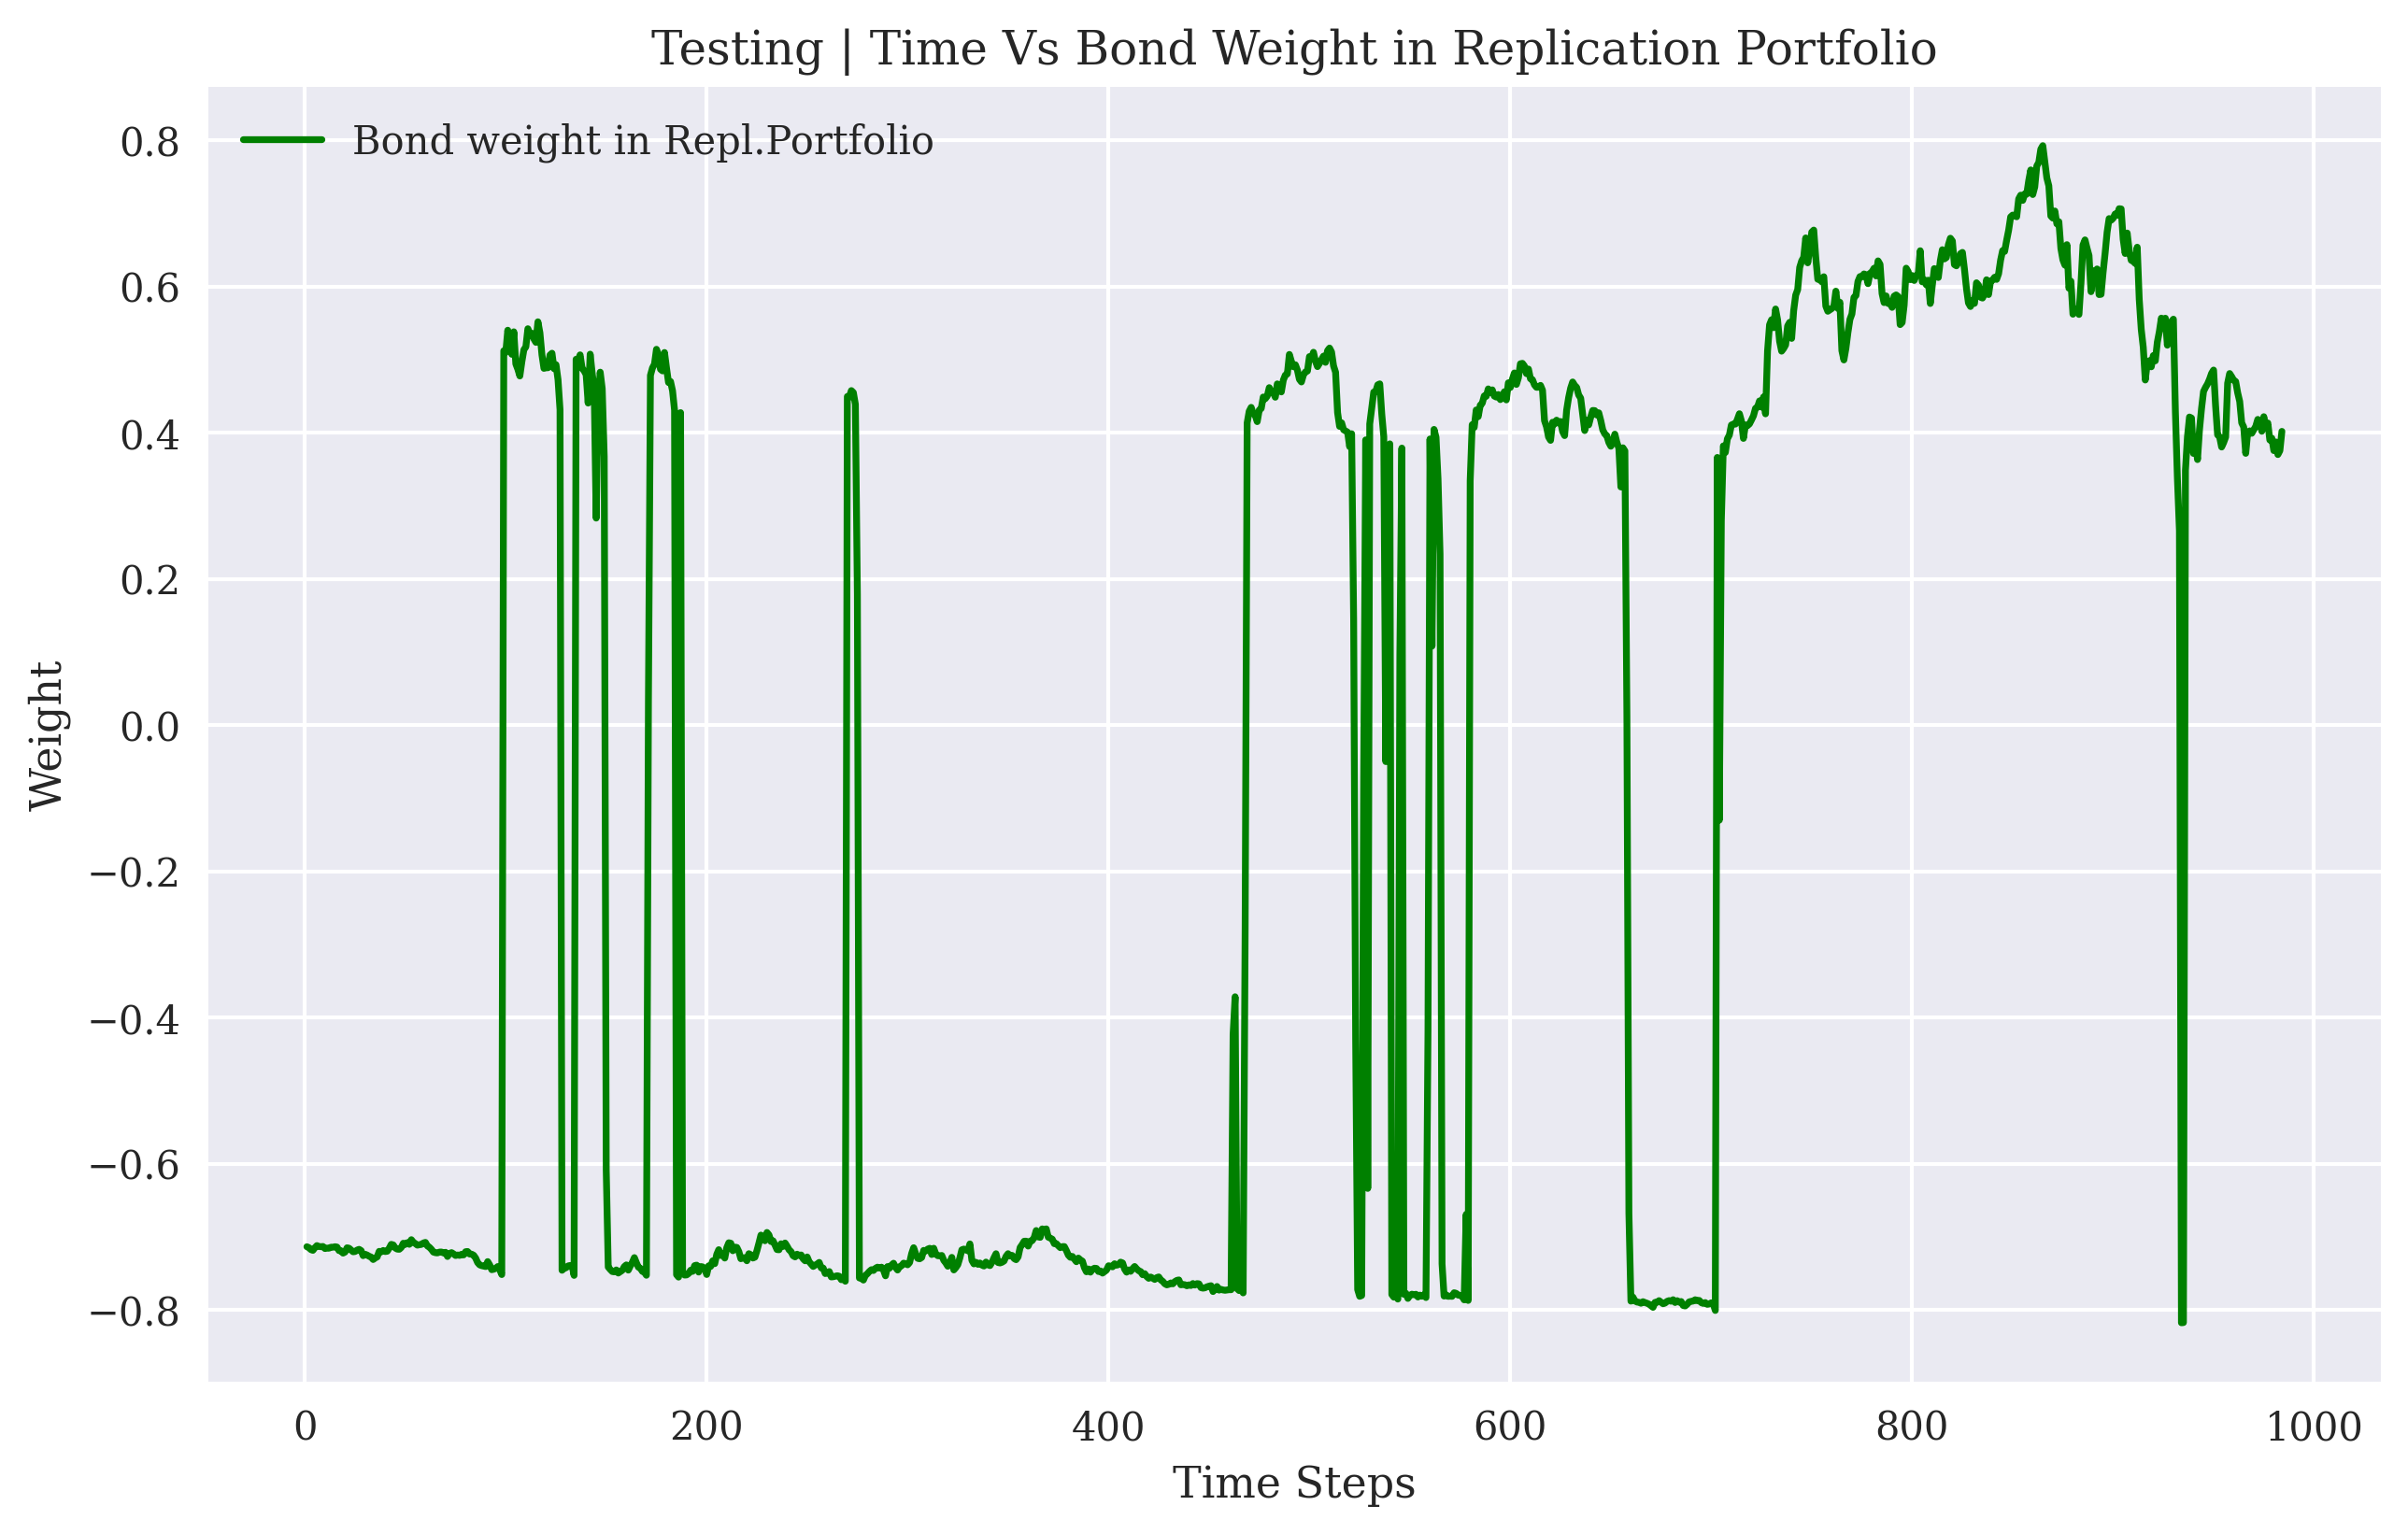

In [10]:
agent.test_agent()